# Treba Python Wrapper Quickstart

This notebook shows a few small, notebook-friendly workflows with `treba_py`:

1. Train and inspect a PFSA from tokenized symbol sequences.
2. Train an HMM from character-level strings.
3. Save and reload models with `from_file(...)`.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "treba").exists() and (REPO_ROOT.parent / "treba").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from treba_py import DrawConfig, HMM, PFSA, TokenizationConfig, TrainingConfig, TrebaRunner

TREBA_BIN = (REPO_ROOT / "treba").resolve()
print("Repo root:", REPO_ROOT)
print("Using Treba binary:", TREBA_BIN)
RUNNER = TrebaRunner(str(TREBA_BIN))

Repo root: /home/ubuntu/dev/treba
Using Treba binary: /home/ubuntu/dev/treba/treba


## 1) PFSA on toy token sequences

In [2]:
X_pfsa = [
    ["walk", "shop", "clean"],
    ["walk", "shop"],
    ["walk", "clean"],
    ["clean", "shop"],
    ["walk", "walk", "shop"],
]

pfsa = PFSA(
    n_states=6,
    training=TrainingConfig(algorithm="bw", max_iter=30),
    runner=RUNNER,
)

pfsa.fit(X_pfsa)
print("PFSA fitted:", pfsa.is_fitted)

PFSA fitted: True


In [3]:
print("Likelihoods:", pfsa.score([["walk", "shop"], ["clean", "shop"]]))
print("Normalized log2 scores:", pfsa.score([["walk", "shop"]], normalized=True))

Likelihoods: [0.20247344315952068, 0.19925730426174815]
Normalized log2 scores: [-1.1520977006909405]


In [4]:
decoded = pfsa.decode([["walk", "shop", "clean"]], with_prob=True)
print(decoded[0])

DecodeResult(states=[0, 5, 4, 3], prob=0.17330220757921086)


In [5]:
samples = pfsa.sample(3, with_states=True)
samples

[SampleResult(tokens=['walk', 'clean'], token_ids=[0, 2], prob=0.04684822779156895, states=[0, 5, 3]),
 SampleResult(tokens=['walk', 'clean'], token_ids=[0, 2], prob=0.1094474388862247, states=[0, 5, 2]),
 SampleResult(tokens=['walk', 'shop'], token_ids=[0, 1], prob=0.03441000750112686, states=[0, 1, 3])]

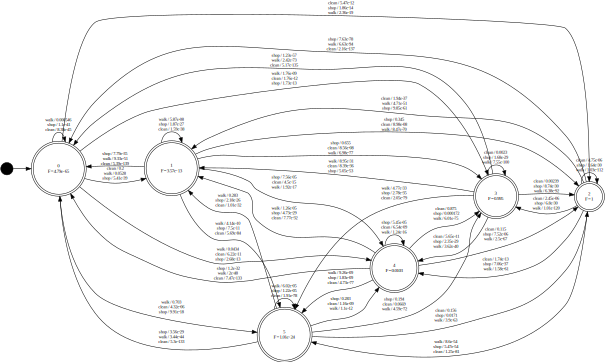

In [6]:
pfsa.draw(config=DrawConfig(rankdir="LR", top_k_emissions=3, prob_precision=3))

## 2) HMM on character-level strings

Setting `token_sep=""` means each character is treated as a token.

In [12]:
X_hmm = [
    "abaaaba",
    "ababa",
    "abaababaaaba",
    "babaaba",
    "baba",
]

hmm = HMM(
    n_states=5,
    token_config=TokenizationConfig(token_sep=""),
    training=TrainingConfig(algorithm="bw", max_iter=2500),
    runner=RUNNER,
)

hmm.fit(X_hmm)
print("HMM fitted:", hmm.is_fitted)

HMM fitted: True


In [13]:
print("HMM score:", hmm.score(["ababa", "bbba"]))
print("HMM decode:", hmm.decode(["abba"], with_prob=True)[0])

HMM score: [0.05539450283213832, 1.3843161591671145e-07]
HMM decode: DecodeResult(states=[0, 2, 2, 3, 1, 4], prob=1.4995458976666056e-06)


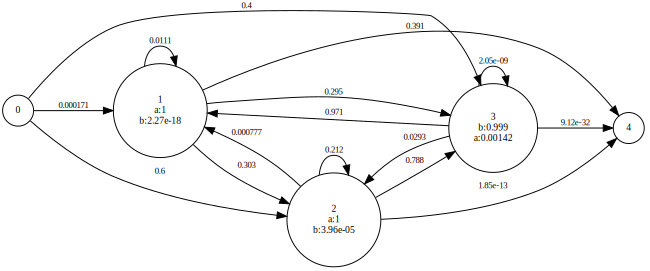

In [14]:
hmm.draw(config=DrawConfig(rankdir="LR", top_k_emissions=4, prob_precision=3))

## 3) Save and reload

In [10]:
artifacts = REPO_ROOT / "notebooks" / "artifacts"
artifacts.mkdir(parents=True, exist_ok=True)

pfsa_path = artifacts / "toy_pfsa.fsm"
hmm_path = artifacts / "toy_hmm.hmm"

pfsa.save(pfsa_path)
hmm.save(hmm_path)

print("Saved:", pfsa_path, hmm_path)

Saved: /home/ubuntu/dev/treba/notebooks/artifacts/toy_pfsa.fsm /home/ubuntu/dev/treba/notebooks/artifacts/toy_hmm.hmm


In [11]:
# Pass an alphabet to restore human-readable labels on reload.
pfsa2 = PFSA.from_file(pfsa_path, alphabet=["walk", "shop", "clean"])
print("Reloaded PFSA score:", pfsa2.score([["walk", "shop"]]))

# For HMM char-level toy data, provide alphabet in symbol-id order.
hmm2 = HMM.from_file(
    hmm_path,
    alphabet=["a", "b"],
    token_config=TokenizationConfig(token_sep=""),
)
print("Reloaded HMM score:", hmm2.score(["abba"]))

Reloaded PFSA score: [0.20247344315952068]
Reloaded HMM score: [4.132093046272917e-09]


## Notes

- For unknown symbols, configure `TokenizationConfig(unknown_policy=...)`.
- If using `unknown_policy="use_unk"`, ensure the unknown token appears in training data,
  otherwise Treba may drop that symbol from the trained alphabet.
- For larger benchmark sweeps, use the `scripts/pautomac_eval.py` and
  `scripts/pautomac_battery.py` tooling.